![](images/VGG-16-arch.jpg)

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
# ImageNet dataset (smaller dataset)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

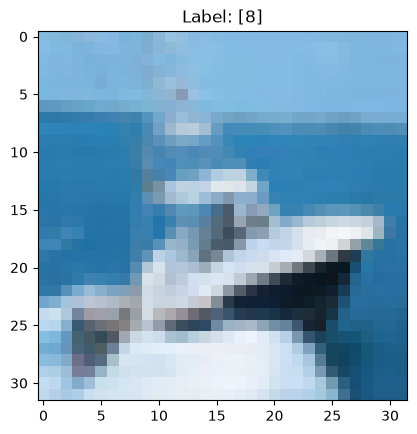

Image Shape: (32, 32, 3)


In [6]:
# See the pictures
sample_index = 8

pic = x_train[sample_index]
plt.imshow(pic)
plt.title(f"Label: {y_train[sample_index]}")
plt.show()
print(f"Image Shape: {x_train[sample_index].shape}")

In [ ]:
Inputs = layers.Input(shape=(32, 32, 3))
Resize = layers.Resizing(224, 224)(Inputs)
Rescal = layers.Rescaling(1.0 / 255)(Resize)

# -----------------------------------------
# Block 1
# Layer 1
Conv_1 = layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Rescal)
Batch_n1 = layers.BatchNormalization()(Conv_1)
# Conv -> BN -> ReLU
Act_1 = layers.Activation("relu")(Batch_n1)

# Layer 2
Conv_2 = layers.Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_1)
Batch_n2 = layers.BatchNormalization()(Conv_2)
Act_2 = layers.Activation("relu")(Batch_n2)
Pool_2 = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(Act_2)

# -----------------------------------------
# Block 2
# Layer 3
Conv_3 = layers.Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Pool_2)
Batch_n3 = layers.BatchNormalization()(Conv_3)
Act_3 = layers.Activation("relu")(Batch_n3)

# Layer 4
Conv_4 = layers.Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_3)
Batch_n4 = layers.BatchNormalization()(Conv_4)
Act_4 = layers.Activation("relu")(Batch_n4)
Pool_4 = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(Act_4)

# -----------------------------------------
# Block 3
# Layer 5
Conv_5 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Pool_4)
Batch_n5 = layers.BatchNormalization()(Conv_5)
Act_5 = layers.Activation("relu")(Batch_n5)

# Layer 6
Conv_6 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_5)
Batch_n6 = layers.BatchNormalization()(Conv_6)
Act_6 = layers.Activation("relu")(Batch_n6)

# Layer 7
Conv_7 = layers.Conv2D(filters=256, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_6)
Batch_n7 = layers.BatchNormalization()(Conv_7)
Act_7 = layers.Activation("relu")(Batch_n7)
Pool_7 = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(Act_7)

# -----------------------------------------
# Block 4
# Layer 8
Conv_8 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Pool_7)
Batch_n8 = layers.BatchNormalization()(Conv_8)
Act_8 = layers.Activation("relu")(Batch_n8)

# Layer 9
Conv_9 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_8)
Batch_n9 = layers.BatchNormalization()(Conv_9)
Act_9 = layers.Activation("relu")(Batch_n9)

# Layer 10
Conv_10 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_9)
Batch_n10 = layers.BatchNormalization()(Conv_10)
Act_10 = layers.Activation("relu")(Batch_n10)
Pool_10 = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(Act_10)

# -----------------------------------------
# Block 5
# Layer 11
Conv_11 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Pool_10)
Batch_n11 = layers.BatchNormalization()(Conv_11)
Act_11 = layers.Activation("relu")(Batch_n11)

# Layer 12
Conv_12 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_11)
Batch_n12 = layers.BatchNormalization()(Conv_12)
Act_12 = layers.Activation("relu")(Batch_n12)

# Layer 13
Conv_13 = layers.Conv2D(filters=512, kernel_size=(3, 3), strides=(1, 1), padding="same", use_bias=False)(Act_12)
Batch_n13 = layers.BatchNormalization()(Conv_13)
Act_13 = layers.Activation("relu")(Batch_n13)
Pool_13 = layers.MaxPooling2D(pool_size=(2, 2), strides=2)(Act_13)

# -----------------------------------------
# Fully Connected Layers (Classifier)
# Layer 14
Flatten = layers.Flatten()(Pool_13)
FC_14 = layers.Dense(units=4096, activation="relu")(Flatten)
Drop_14 = layers.Dropout(0.5)(FC_14)

# Layer 15
FC_15 = layers.Dense(units=4096, activation="relu")(Drop_14)
Drop_15 = layers.Dropout(0.5)(FC_15)

# Layer 16 (Output Layer)
output = layers.Dense(units=10, activation="softmax")(Drop_15)

VGG_Model = models.Model(inputs=Inputs, outputs=output, name="VGG-16-BN")

In [10]:
VGG_Model = models.Model(inputs=Inputs, outputs=output, name="VGG-16")

In [11]:
VGG_Model.summary()

Model: "VGG-16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        40,97

 Total params: 134,301,514 (512.32 MB)

 Trainable params: 134,301,514 (512.32 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
VGG_Model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
History = VGG_Model.fit(
    x = x_train,
    y = y_train,
    batch_size=64,
    epochs=10,
    validation_data= (x_test, y_test)
)

In [ ]:
# evaluate
test_loss, test_acc = VGG_Model.evaluate(x=x_test, y=y_test, verbose=0)
print(f"Test Accauray is: {test_acc * 100}")

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(History.history["loss"], label="Train Loss")
plt.plot(History.history["val_loss"], label="Val Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(History.history["accuracy"], label="Train Accuracy")
plt.plot(History.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()